# Woche 7: Data Cleaning - Übung am eigenen Projekt

**Ziel dieser Übung:** Nachdem Sie die wichtigsten Aspekte des Data Cleanings am Airbnb-Beispiel kennengelernt haben, wenden Sie dieses Wissen Schritt für Schritt auf Ihren eigenen Datensatz an.

**Arbeitsweise:**
- Arbeiten Sie die Aufgaben nacheinander durch
- Nutzen Sie die Code-Zellen für Ihre Implementierung
- Orientieren Sie sich an den Beispielen aus dem Airbnb-Notebook
- Das bereinigte Dataset speichern Sie am Ende ab

---
## 1. Daten einlesen und Bibliotheken importieren

**Aufgabe:** Importieren Sie die notwendigen Bibliotheken und laden Sie Ihren Datensatz.

**Hinweise:**
- Importieren Sie: `pandas`, `numpy`, `matplotlib.pyplot`, `seaborn`
- Setzen Sie einen Zufallsseed für Reproduzierbarkeit
- Laden Sie Ihren CSV-Datensatz mit `pd.read_csv()`

In [21]:
# Bibliotheken importieren
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Zufallsseed setzen
np.random.seed(42)

# Datensatz einlesen
df = pd.read_csv("../data/raw/ai_job_market_insights.csv")

In [22]:
# Erste Zeilen anzeigen
df.head()

,Job_Title,Industry,Company_Size,Location,AI_Adoption_Level,Automation_Risk,Required_Skills,Salary_USD,Remote_Friendly,Job_Growth_Projection
0,Cybersecurity Analyst,Entertainment,Small,Dubai,Medium,High,UX/UI Design,111392.165243,Yes,Growth
1,Marketing Specialist,Technology,Large,Singapore,Medium,High,Marketing,93792.562466,No,Decline
2,AI Researcher,Technology,Large,Singapore,Medium,High,UX/UI Design,107170.263069,Yes,Growth
3,Sales Manager,Retail,Small,Berlin,Low,High,Project Management,93027.953758,No,Growth
4,Cybersecurity Analyst,Entertainment,Small,Tokyo,Low,Low,JavaScript,87752.922171,Yes,Decline


---
## 2. Ersten Überblick verschaffen

**Aufgabe:** Verschaffen Sie sich einen ersten Überblick über Ihren Datensatz.

**Was Sie prüfen sollten:**
- Wie viele Zeilen und Spalten hat der Datensatz?
- Welche Spalten gibt es und welche Datentypen haben sie?
- Wie sehen die ersten Zeilen aus?

In [23]:
# Dimensionen des Datensatzes
print("Anzahl Zeilen und Spalten:")
print(df.shape)

# Informationen zu Spalten und Datentypen
df.info()

Anzahl Zeilen und Spalten:
(500, 10)
<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Job_Title              500 non-null    str    
 1   Industry               500 non-null    str    
 2   Company_Size           500 non-null    str    
 3   Location               500 non-null    str    
 4   AI_Adoption_Level      500 non-null    str    
 5   Automation_Risk        500 non-null    str    
 6   Required_Skills        500 non-null    str    
 7   Salary_USD             500 non-null    float64
 8   Remote_Friendly        500 non-null    str    
 9   Job_Growth_Projection  500 non-null    str    
dtypes: float64(1), str(9)
memory usage: 39.2 KB


---
## 3. Fehlende Werte identifizieren

**Aufgabe:** Untersuchen Sie Ihren Datensatz auf fehlende Werte.

**Was Sie tun sollten:**
- Zählen Sie fehlende Werte pro Spalte
- Berechnen Sie den Prozentsatz fehlender Werte
- Visualisieren Sie fehlende Werte (optional: Heatmap)

Fehlende Werte pro Spalte:
Job_Title                0
Industry                 0
Company_Size             0
Location                 0
AI_Adoption_Level        0
Automation_Risk          0
Required_Skills          0
Salary_USD               0
Remote_Friendly          0
Job_Growth_Projection    0
dtype: int64
Prozentsatz fehlender Werte pro Spalte:
Job_Title                0.0
Industry                 0.0
Company_Size             0.0
Location                 0.0
AI_Adoption_Level        0.0
Automation_Risk          0.0
Required_Skills          0.0
Salary_USD               0.0
Remote_Friendly          0.0
Job_Growth_Projection    0.0
dtype: float64


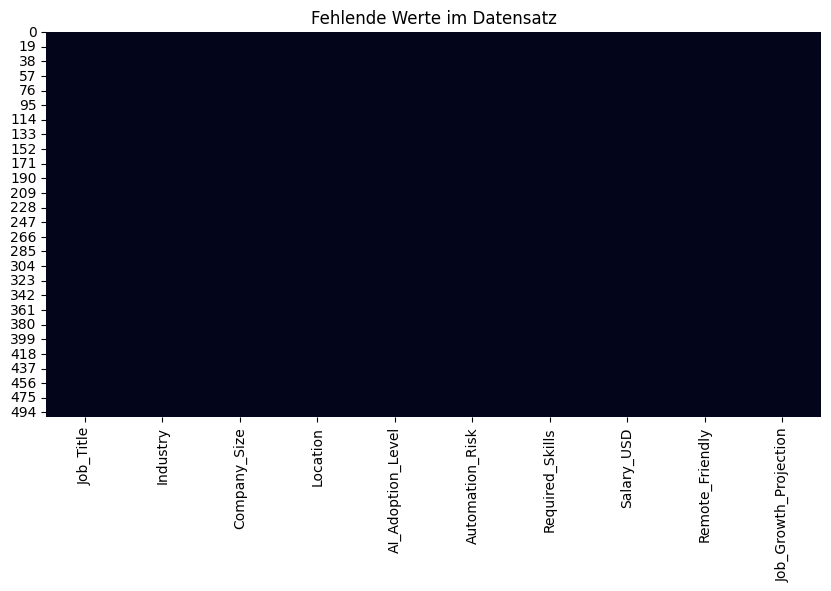

In [24]:
# Fehlende Werte zählen
missing_values = df.isnull().sum()

print("Fehlende Werte pro Spalte:")
print(missing_values)

# Prozentsatz fehlender Werte berechnen
missing_percentage = (df.isnull().sum() / len(df)) * 100

print("Prozentsatz fehlender Werte pro Spalte:")
print(missing_percentage)

# Optional: Visualisierung mit Heatmap
plt.figure(figsize=(10, 5))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Fehlende Werte im Datensatz")
plt.show()

---
## 4. Fehlende Werte behandeln

**Aufgabe:** Entscheiden Sie für jede Spalte mit fehlenden Werten, wie Sie damit umgehen.

**Mögliche Strategien:**
- Zeilen löschen (bei wenigen fehlenden Werten)
- Spalten löschen (bei sehr vielen fehlenden Werten)
- Fehlende Werte imputieren:
  - Numerische Spalten: Median oder Mittelwert
  - Kategoriale Spalten: Modus oder neue Kategorie

**Dokumentieren Sie Ihre Entscheidungen!**

In [25]:
# Eine Kopie des Datensatzes erstellen, damit das Original erhalten bleibt
df_clean = df.copy()

# Überprüfen, ob fehlende Werte vorhanden sind
missing_values_total = df_clean.isnull().sum().sum()

print("Gesamtanzahl fehlender Werte:", missing_values_total)

# Entscheidung zur Behandlung fehlender Werte
if missing_values_total == 0:
    print("Es gibt keine fehlenden Werte. Keine Behandlung notwendig.")
else:
    print("Es gibt fehlende Werte. Eine Behandlung wäre notwendig.")


Gesamtanzahl fehlender Werte: 0
Es gibt keine fehlenden Werte. Keine Behandlung notwendig.


In [26]:
# Überprüfung: Sind alle fehlenden Werte behandelt?
print("Fehlende Werte nach der Behandlung:")
print(df_clean.isnull().sum())

Fehlende Werte nach der Behandlung:
Job_Title                0
Industry                 0
Company_Size             0
Location                 0
AI_Adoption_Level        0
Automation_Risk          0
Required_Skills          0
Salary_USD               0
Remote_Friendly          0
Job_Growth_Projection    0
dtype: int64


---
## 5. Duplikate identifizieren und entfernen

**Aufgabe:** Prüfen Sie, ob Ihr Datensatz doppelte Zeilen enthält.

**Was Sie tun sollten:**
- Zählen Sie die Anzahl doppelter Zeilen
- Entfernen Sie Duplikate (falls vorhanden)
- Überprüfen Sie die neue Anzahl der Zeilen

In [27]:
# Anzahl doppelter Zeilen
duplicates = df_clean.duplicated().sum()

print("Anzahl doppelter Zeilen:", duplicates)

# Duplikate entfernen
if duplicates > 0:
    df_clean = df_clean.drop_duplicates()
    print("Duplikate wurden entfernt.")
else:
    print("Es wurden keine Duplikate gefunden. Keine Entfernung notwendig.")

# Neue Dimensionen prüfen
print("Dimensionen nach der Duplikatprüfung:")
print(df_clean.shape)

Anzahl doppelter Zeilen: 0
Es wurden keine Duplikate gefunden. Keine Entfernung notwendig.
Dimensionen nach der Duplikatprüfung:
(500, 10)


---
## 6. Datentypen überprüfen und anpassen

**Aufgabe:** Stellen Sie sicher, dass alle Spalten die richtigen Datentypen haben.

**Was Sie prüfen sollten:**
- Sind numerische Spalten als `int` oder `float` kodiert?
- Sind kategoriale Spalten als `object` oder `category` kodiert?
- Müssen Datentypen konvertiert werden?

In [28]:
# Datentypen anzeigen
df_clean.dtypes

# Datentypen konvertieren (falls nötig)
category_columns = [
    "Job_Title",
    "Industry",
    "Company_Size",
    "Location",
    "AI_Adoption_Level",
    "Automation_Risk",
    "Required_Skills",
    "Job_Growth_Projection"
]

for col in category_columns:
    df_clean[col] = df_clean[col].astype("category")
    

In [29]:
# Numerische Spalte sicherheitshalber als int setzen
df_clean["Salary_USD"] = df_clean["Salary_USD"].round().astype("int")

In [30]:
# Remote_Friendly von Yes/No zu 1/0 umwandeln
df_clean["Remote_Friendly"] = df_clean["Remote_Friendly"].astype(str).str.strip()

df_clean["Remote_Friendly"] = df_clean["Remote_Friendly"].map({
    "Yes": 1,
    "No": 0
}).astype(int)

In [31]:
# Datentypen nach der Anpassung überprüfen
df_clean.dtypes

Job_Title                category
Industry                 category
Company_Size             category
Location                 category
AI_Adoption_Level        category
Automation_Risk          category
Required_Skills          category
Salary_USD                  int64
Remote_Friendly             int64
Job_Growth_Projection    category
dtype: object

In [32]:
# Kontrolle
df_clean["Remote_Friendly"].value_counts()

Remote_Friendly
1    251
0    249
Name: count, dtype: int64

---
## 7. Ausreißer identifizieren

**Aufgabe:** Identifizieren Sie Ausreißer in numerischen Spalten.

**Methoden:**
- Visualisierung mit Boxplots
- IQR-Methode (Interquartile Range)
- Statistische Analyse (describe)

**Wichtig:** Entscheiden Sie für jeden Ausreißer, ob er:
- Ein Fehler ist (→ entfernen oder korrigieren)
- Ein echter extremer Wert ist (→ behalten)

In [33]:
# Statistische Übersicht für Salary_USD
display(df_clean[["Salary_USD"]].describe().round(2))

# Prozentuale Verteilung von Remote_Friendly
remote_table = df_clean["Remote_Friendly"].map({
    1: "Yes",
    0: "No"
}).value_counts(normalize=True) * 100

remote_table = remote_table.round(1).to_frame(name="Percentage (%)")

display(remote_table)


,Salary_USD
count,500.00
mean,91222.42
std,20504.27
min,31970.00
25%,78511.25
50%,91998.00
75%,103971.75
max,155210.00


,Percentage (%)
Remote_Friendly,
Yes,50.2
No,49.8


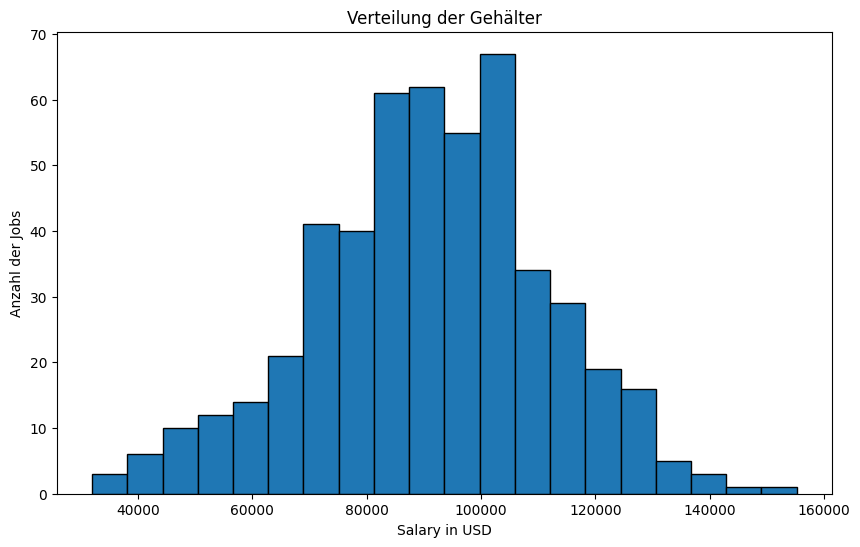

In [34]:
# Histogramm für Salary_USD
plt.figure(figsize=(10, 6))
plt.hist(df_clean["Salary_USD"], bins=20, edgecolor="black")

plt.title("Verteilung der Gehälter")
plt.xlabel("Salary in USD")
plt.ylabel("Anzahl der Jobs")

plt.show()

In [35]:
# Ausreißer mit IQR-Methode identifizieren (Beispiel für eine Spalte)
Q1 = df_clean["Salary_USD"].quantile(0.25)
Q3 = df_clean["Salary_USD"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df_clean[
    (df_clean["Salary_USD"] < lower_bound) |
    (df_clean["Salary_USD"] > upper_bound)
]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Untere Grenze:", lower_bound)
print("Obere Grenze:", upper_bound)
print("Anzahl Ausreißer:", len(outliers))

outliers.head()

Q1: 78511.25
Q3: 103971.75
IQR: 25460.5
Untere Grenze: 40320.5
Obere Grenze: 142162.5
Anzahl Ausreißer: 5


,Job_Title,Industry,Company_Size,Location,AI_Adoption_Level,Automation_Risk,Required_Skills,Salary_USD,Remote_Friendly,Job_Growth_Projection
182,Data Scientist,Transportation,Small,New York,Low,Low,Python,31970,1,Growth
289,Data Scientist,Healthcare,Medium,Paris,High,Low,Python,148467,1,Stable
384,Cybersecurity Analyst,Telecommunications,Large,Berlin,Low,Medium,UX/UI Design,33601,0,Stable
420,Marketing Specialist,Finance,Medium,San Francisco,High,High,Sales,155210,1,Decline
425,UX Designer,Entertainment,Small,Singapore,Medium,Medium,Data Analysis,35963,0,Decline


---
## 8. Ausreißer behandeln

**Aufgabe:** Behandeln Sie die identifizierten Ausreißer entsprechend Ihrer Analyse.

**Mögliche Strategien:**
- Ausreißer entfernen (wenn sie Fehler sind)
- Ausreißer behalten (wenn sie valide sind)
- Ausreißer begrenzen (Capping/Flooring)

**Dokumentieren Sie Ihre Entscheidungen!**

In [36]:

print("Anzahl der identifizierten Ausreißer:", len(outliers))

print("Die Ausreißer werden nicht entfernt, da es sich bei Gehältern um realistische Extremwerte handeln kann.")
print("Der Datensatz bleibt daher unverändert.")

# Dimensionen prüfen
print("Dimensionen nach der Ausreißerbehandlung:")
print(df_clean.shape)


Anzahl der identifizierten Ausreißer: 5
Die Ausreißer werden nicht entfernt, da es sich bei Gehältern um realistische Extremwerte handeln kann.
Der Datensatz bleibt daher unverändert.
Dimensionen nach der Ausreißerbehandlung:
(500, 10)


In [37]:
# Überprüfung der Gehaltsspalte nach der Entscheidung
df_clean["Salary_USD"].describe().round(2)

count       500.00
mean      91222.42
std       20504.27
min       31970.00
25%       78511.25
50%       91998.00
75%      103971.75
max      155210.00
Name: Salary_USD, dtype: float64

---
## 9. Inkonsistenzen beheben

**Aufgabe:** Suchen Sie nach Inkonsistenzen in kategorialen Spalten.

**Was Sie prüfen sollten:**
- Unterschiedliche Schreibweisen (z.B. "ja", "Ja", "JA")
- Leerzeichen am Anfang oder Ende
- Tippfehler
- Unerwartete Kategorien

In [38]:
# Kategoriale Spalten auswählen
categorical_cols = df_clean.select_dtypes(include=["category"]).columns

# Einzigartige Werte pro kategorialer Spalte anzeigen
for col in categorical_cols:
    print(f"\nSpalte: {col}")
    print(df_clean[col].value_counts())



Spalte: Job_Title
Job_Title
Data Scientist           62
HR Manager               57
Cybersecurity Analyst    55
UX Designer              54
AI Researcher            51
Sales Manager            49
Marketing Specialist     48
Operations Manager       44
Software Engineer        41
Product Manager          39
Name: count, dtype: int64

Spalte: Industry
Industry
Manufacturing         58
Education             57
Technology            56
Finance               53
Telecommunications    53
Energy                49
Entertainment         47
Retail                46
Healthcare            42
Transportation        39
Name: count, dtype: int64

Spalte: Company_Size
Company_Size
Small     171
Large     166
Medium    163
Name: count, dtype: int64

Spalte: Location
Location
San Francisco    62
Singapore        54
Sydney           52
Dubai            51
Tokyo            51
New York         49
Berlin           48
London           46
Paris            46
Toronto          41
Name: count, dtype: int64

Spalt

In [39]:
for col in categorical_cols:
    df_clean[col] = df_clean[col].astype(str).str.strip()
    df_clean[col] = df_clean[col].astype("category")

In [40]:
for col in categorical_cols:
    print(f"\nSpalte: {col}")
    print(df_clean[col].value_counts())


Spalte: Job_Title
Job_Title
Data Scientist           62
HR Manager               57
Cybersecurity Analyst    55
UX Designer              54
AI Researcher            51
Sales Manager            49
Marketing Specialist     48
Operations Manager       44
Software Engineer        41
Product Manager          39
Name: count, dtype: int64

Spalte: Industry
Industry
Manufacturing         58
Education             57
Technology            56
Finance               53
Telecommunications    53
Energy                49
Entertainment         47
Retail                46
Healthcare            42
Transportation        39
Name: count, dtype: int64

Spalte: Company_Size
Company_Size
Small     171
Large     166
Medium    163
Name: count, dtype: int64

Spalte: Location
Location
San Francisco    62
Singapore        54
Sydney           52
Dubai            51
Tokyo            51
New York         49
Berlin           48
London           46
Paris            46
Toronto          41
Name: count, dtype: int64

Spalt

---
## 10. Finale Überprüfung

**Aufgabe:** Führen Sie eine finale Qualitätskontrolle durch.

**Checkliste:**
- ✓ Keine fehlenden Werte (oder bewusst belassen)
- ✓ Keine Duplikate
- ✓ Korrekte Datentypen
- ✓ Ausreißer behandelt
- ✓ Inkonsistenzen behoben
- ✓ Datensatz ist bereit für die Analyse

In [41]:
# Finale Übersicht
print("Finale Dimensionen:")
print(df_clean.shape)

print("\nFehlende Werte:")
print(df_clean.isnull().sum())

print("\nAnzahl doppelter Zeilen:")
print(df_clean.duplicated().sum())

print("\nDatentypen:")
print(df_clean.dtypes)

print("\nErste Zeilen des bereinigten Datensatzes:")
display(df_clean.head())

Finale Dimensionen:
(500, 10)

Fehlende Werte:
Job_Title                0
Industry                 0
Company_Size             0
Location                 0
AI_Adoption_Level        0
Automation_Risk          0
Required_Skills          0
Salary_USD               0
Remote_Friendly          0
Job_Growth_Projection    0
dtype: int64

Anzahl doppelter Zeilen:
0

Datentypen:
Job_Title                category
Industry                 category
Company_Size             category
Location                 category
AI_Adoption_Level        category
Automation_Risk          category
Required_Skills          category
Salary_USD                  int64
Remote_Friendly             int64
Job_Growth_Projection    category
dtype: object

Erste Zeilen des bereinigten Datensatzes:


,Job_Title,Industry,Company_Size,Location,AI_Adoption_Level,Automation_Risk,Required_Skills,Salary_USD,Remote_Friendly,Job_Growth_Projection
0,Cybersecurity Analyst,Entertainment,Small,Dubai,Medium,High,UX/UI Design,111392,1,Growth
1,Marketing Specialist,Technology,Large,Singapore,Medium,High,Marketing,93793,0,Decline
2,AI Researcher,Technology,Large,Singapore,Medium,High,UX/UI Design,107170,1,Growth
3,Sales Manager,Retail,Small,Berlin,Low,High,Project Management,93028,0,Growth
4,Cybersecurity Analyst,Entertainment,Small,Tokyo,Low,Low,JavaScript,87753,1,Decline


In [42]:
# Finale statistische Übersicht
df_clean.describe(include="all")

,Job_Title,Industry,Company_Size,Location,AI_Adoption_Level,Automation_Risk,Required_Skills,Salary_USD,Remote_Friendly,Job_Growth_Projection
count,500,500,500,500,500,500,500,500.000000,500.000000,500
unique,10,10,3,10,3,3,10,NaN,NaN,3
top,Data Scientist,Manufacturing,Small,San Francisco,Medium,Medium,Project Management,NaN,NaN,Decline
freq,62,58,171,62,179,173,60,NaN,NaN,169
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,91222.424000,0.502000,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20504.274931,0.500497,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,31970.000000,0.000000,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,78511.250000,0.000000,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,91998.000000,1.000000,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,103971.750000,1.000000,NaN


---
## 11. Bereinigten Datensatz speichern

**Aufgabe:** Speichern Sie Ihren bereinigten Datensatz als CSV-Datei.

**Wichtig:** Dieser bereinigte Datensatz wird in den kommenden Wochen für Visualisierung und Machine Learning verwendet!

In [45]:
# Bereinigten Datensatz speichern
# df.to_csv('ihr_datensatz_cleaned.csv', index=False)
df_clean.to_csv("../data/cleaned/ai_job_market_insights_cleaned.csv", index=False)

print("Bereinigter Datensatz wurde gespeichert!")

Bereinigter Datensatz wurde gespeichert!


In [46]:
df_test = pd.read_csv("ai_job_market_insights_cleaned.csv")

print("Dimensionen der gespeicherten Datei:")
print(df_test.shape)

df_test.head()

FileNotFoundError: [Errno 2] No such file or directory: 'ai_job_market_insights_cleaned.csv'

---
## Reflexion

**Dokumentieren Sie Ihre Arbeit:**

Beantworten Sie folgende Fragen in einer Markdown-Zelle:

1. Welche Hauptprobleme hatte Ihr ursprünglicher Datensatz?
2. Welche Bereinigungsschritte waren am wichtigsten?
3. Wie viele Zeilen/Spalten haben Sie entfernt und warum?
4. Welche Herausforderungen gab es und wie haben Sie diese gelöst?
5. Ist Ihr Datensatz jetzt bereit für die Analyse?

### Reflexion

1. **Hauptprobleme:**
   - Der Datensatz musste auf fehlende Werte, Duplikate, Datentypen und mögliche Ausreißer überprüft werden.
   - Einige Spalten mussten für die spätere Analyse angepasst werden, beispielsweise „Salary_USD“ und „Remote_Friendly“.

2. **Wichtige Schritte:**
   - Überprüfung auf fehlende Werte und Duplikate.
   - Umwandlung von „Salary_USD“ in einen ganzzahligen Datentyp.
   - Umwandlung von „Remote_Friendly“ von „Ja/Nein“ in „1/0“.
   - Analyse der Gehaltsverteilung mithilfe eines Histogramms und der IQR-Methode.

3. **Entfernte Daten:**
   - Es wurden keine Zeilen oder Spalten entfernt, da keine fehlenden Werte oder Duplikate vorlagen.
   - Die identifizierten Gehaltsausreißer wurden nicht entfernt, da hohe Gehälter realistische Werte sein können.

4. **Herausforderungen:**
   - Entscheidung, ob Gehaltsausreißer entfernt werden sollen.
   - Angemessene Darstellung binärer Variablen wie „Remote_Friendly“.

5. **Bereit für die Analyse:**
   - Der Datensatz wurde bereinigt und ist bereit für die Visualisierung, Analyse und das maschinelle Lernen.

Übersetzt mit DeepL.com (kostenlose Version)